In [131]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from scipy.stats import f_oneway
from itertools import combinations
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import glob
import pingouin as pg
from scipy.stats import ttest_ind 
import statsmodels.formula.api as smf



# Important functions

In [65]:
def analyze_groups_anova(df, score_col, group_col):
    # Extract data for each group
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == group][score_col].dropna() for group in groups]
    
    # Combine all groups into one dataset
    all_data = pd.concat(group_data)
    grand_mean = all_data.mean()

    # Calculate Sum of Squares Between (SS_between)
    SS_between = sum(len(group) * (group.mean() - grand_mean)**2 for group in group_data)

    # Calculate Sum of Squares Within (SS_within)
    SS_within = sum(sum((group - group.mean())**2) for group in group_data)

    # Calculate Total Sum of Squares (SS_total)
    SS_total = SS_between + SS_within

    # Calculate Eta Squared (η²)
    eta_squared = SS_between / SS_total

    # Perform one-way ANOVA
    stat, p = f_oneway(*group_data)

    # Print results
    print("SS stands for Sum of Squares")
    print(f"SS_between: {SS_between:.4f}")
    print(f"SS_within: {SS_within:.4f}")
    print(f"SS_total: {SS_total:.4f}")
    print(f"Effect Size (Eta Squared, η²): {eta_squared:.4f}")
    print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("There is a significant difference between the groups.")
    else:
        print("No significant difference between the groups.")

    # Plot the scores for each group
    plt.figure(figsize=(8, 6))
    boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)
    plt.title(f"{score_col} by {group_col}")

    # Assign different colors to each group
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for box, color in zip(boxplot['boxes'], colors):
        box.set_facecolor(color)

    plt.ylabel(score_col)
    plt.xlabel(group_col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Return results as a dictionary
    return {
        "SS_between": SS_between,
        "SS_within": SS_within,
        "SS_total": SS_total,
        "eta_squared": eta_squared,
        "anova_stat": stat,
        "anova_p_value": p
    }

In [66]:
def analyze_kruskal_test(df, score_col, group_col):
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == group][score_col].dropna() for group in groups]
    stat, p = kruskal(*group_data)
    print(f"Kruskal-Wallis test statistic = {stat:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("There is a significant difference between the groups.")
    else:
        print("No significant difference between the groups.")
    plt.figure(figsize=(8, 6))
    boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)
    plt.title(f"{score_col} by {group_col} (Kruskal-Wallis Test)")
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for box, color in zip(boxplot['boxes'], colors):
        box.set_facecolor(color)

    plt.ylabel(score_col)
    plt.xlabel(group_col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Return results as a dictionary
    return {
        "kruskal_stat": stat,
        "kruskal_p_value": p
    }

In [67]:
def calculate_omega(data):
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(data)
    loadings = fa.loadings_[:, 0]
    uniquenesses = fa.get_uniquenesses()
    numerator = np.sum(loadings)**2
    denominator = numerator + np.sum(uniquenesses)
    return numerator / denominator

In [68]:
# score meaning is (Source: Steiner, 2003, p102)
def interpret_omega(score):
    if score > 0.9:
        return "Excellent"
    elif 0.7 <= score <= 0.9:
        return "Good"
    elif 0.6 <= score < 0.7:
        return "Acceptable"
    elif 0.5 <= score < 0.6:
        return "Poor"
    else:
        return "Unacceptable"

In [69]:
def testing_for_assumptions_by_group(df, score_col="IEQ Score", group_col="Group"):
    print(f"# Testing assumptions for {score_col} #\n")

    groups = df[group_col].unique()
    group_data = {g: df[df[group_col] == g][score_col].dropna() for g in groups}

    # 1. Shapiro–Wilk Test for Normality
    print("## Shapiro–Wilk Test for Normality ##")
    normality = {}
    for group, data in group_data.items():
        print(f"Group {group}:")
        if len(data) < 3:
            print(f"  ⚠️ Not enough data (n={len(data)}) to test normality.\n")
            normality[group] = False
            continue
        stat, p = shapiro(data)
        normal = p > 0.05
        normality[group] = normal
        if normal:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Data appears normal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Data not normal\n")

    print("## Levene’s Test for Equal Variances ##")
    data_lists = [d for d in group_data.values() if len(d) >= 2]
    if len(data_lists) >= 2:
        stat, p = levene(*data_lists)
        equal_var = p > 0.05
        if equal_var:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Variances are equal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Variances are not equal\n")
    else:
        equal_var = False
        print("  ⚠️ Not enough groups with sufficient data to test variance\n")

    print(f"# Final Group Comparison Test for {score_col} #")
    normal_all = all(normality.values())
    sufficient_groups = len([group_data[g] for g in groups if len(group_data[g]) >= 2]) > 2
    if normal_all and equal_var:
        print("✅ All assumptions met. Running ANOVA:")
        if(sufficient_groups):
            stat, p = f_oneway(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ ANOVA Stat = {stat:.4f}, p = {p:.4f}")
        return 1
    else:
        print("❌ Assumptions not met. Using non-parametric Kruskal–Wallis:")
        if(sufficient_groups):
            stat, p = kruskal(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ Kruskal–Wallis Stat = {stat:.4f}, p = {p:.4f}")
        return 0


In [70]:
def print_out_latex_from_dataframe(df, name=None):
    clean_headers = [col.replace('-', ' ').replace('_', ' ').title() for col in df.columns]
    df_clean = df.copy()
    df_clean.columns = clean_headers

    if name is None:
        name = "_".join([h.replace(' ', '') for h in clean_headers[:3]]) + "_table"

    stringheader = ", ".join(clean_headers)
    print(
        "\\begin{figure}\n"
        "\\centering\n"
        f"{df_clean.to_latex(index=False, float_format='%.2f', escape=False)}\n"
        f"\\caption{{A table showing the {name.replace('_', ' ')} with the headers: {stringheader}}}\n"
        f"\\label{{tab:{name}}}\n"
        "\\end{figure}\n"
    )

# Pre-Questionnaire Data Processingprocessing

Load the xlsx file

In [71]:
pre_path = glob.glob("Qustionare_data\\Pre\\*.xlsx")[0]
print(pre_path)
df = pd.read_excel(pre_path, sheet_name=0)
columns_to_plot = [
    "What is your age?",
    "Do you use glasses?",
    "VR",
    "Bartending",
    "Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?"
]
df 

Qustionare_data\Pre\MED 802 Test survey (Part 1)(1-45).xlsx


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Do you consent?,What is your age?,Do you use glasses?,VR,Bartending,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Your test Number (Get your test conductor to fill this out)
0,4,2025-05-05 11:33:00,2025-05-05 11:33:12,anonymous,NaN,NaN,Yes,25-34,No,A lot,NaN,Minor heart condition;,1
1,5,2025-05-05 11:55:57,2025-05-05 12:05:58,anonymous,NaN,NaN,Yes,25-34,Yes,Medium,Quite a bit,Caffeine;,2
2,6,2025-05-05 14:01:59,2025-05-05 14:04:33,anonymous,NaN,NaN,Yes,25-34,No,Medium,Medium,Matcha;,3
3,7,2025-05-05 14:35:11,2025-05-05 14:36:29,anonymous,NaN,NaN,Yes,18-24,No,A little,NaN,None;,4
4,8,2025-05-05 14:56:05,2025-05-05 14:57:19,anonymous,NaN,NaN,Yes,25-34,No,Quite a bit,A little,Caffeine;,5
5,9,2025-05-06 09:06:37,2025-05-06 09:35:53,anonymous,NaN,NaN,Yes,18-24,I'm using lenses right now,A little,NaN,None;,6
6,10,2025-05-06 09:37:24,2025-05-06 10:03:18,anonymous,NaN,NaN,Yes,18-24,No,A little,Medium,Caffeine;,7
7,11,2025-05-06 10:03:21,2025-05-06 10:31:30,anonymous,NaN,NaN,Yes,18-24,Yes,A little,NaN,Caffeine;,8
8,12,2025-05-06 10:32:24,2025-05-06 11:02:29,anonymous,NaN,NaN,Yes,18-24,Yes,A little,NaN,None;,9
9,13,2025-05-06 12:34:07,2025-05-06 12:34:12,anonymous,NaN,NaN,Yes,18-24,Yes,NaN,Medium,Caffeine;,10


In [72]:
# Initialize an empty DataFrame to store the results
answer_counts_df = pd.DataFrame()

for column in columns_to_plot:
    # Extract data from each column, count unique answers, and add to the new DataFrame
    answer_counts = df[column].value_counts().reset_index()
    
    answer_counts.columns = [column, "Count"]
    answer_counts_df = pd.concat([answer_counts_df, answer_counts], axis=1)

# Calculate z-scores for each column with numerical data
z_scores = answer_counts_df.select_dtypes(include=['float64', 'int64']).apply(stats.zscore)

answer_counts_df['Outlier'] = (z_scores.abs() > 3).any(axis=1)

answer_counts_df

,What is your age?,Count,Do you use glasses?,Count,VR,Count,Bartending,Count,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Count,Outlier
0,25-34,23.0,No,30.0,Medium,12.0,Medium,10.0,None;,24,False
1,18-24,22.0,Yes,12.0,A little,11.0,A little,10.0,Caffeine;,14,False
2,NaN,NaN,I'm using lenses right now,3.0,Quite a bit,10.0,Quite a bit,7.0,Minor heart condition;,1,False
3,NaN,NaN,NaN,NaN,A lot,8.0,A lot,1.0,Matcha;,1,False
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medicine ;,1,False
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A wittle bit sick;,1,False
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"if HRT counts, then that;",1,False
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Caffeine;Mango Loco monner;,1,False
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Caffeine;Medicine ;,1,False


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\750008034.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="VR", palette="viridis")


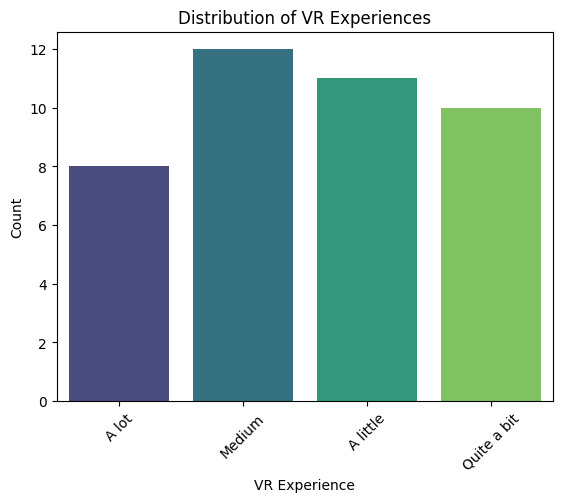

In [73]:
sns.countplot(data=df, x="VR", palette="viridis")
plt.title("Distribution of VR Experiences")
plt.xlabel("VR Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\3884211921.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Bartending", palette="viridis")


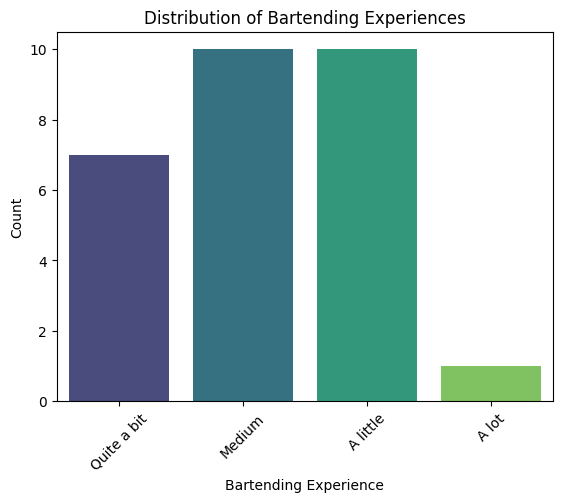

In [74]:
sns.countplot(data=df, x="Bartending", palette="viridis")
plt.title("Distribution of Bartending Experiences")
plt.xlabel("Bartending Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Post-Questionaire Data Processing

In [75]:
post_path = glob.glob("Qustionare_data\\Post\\*.xlsx")[0]
print(post_path)
df_post = pd.read_excel(post_path, sheet_name=0)
df_post 

Qustionare_data\Post\MED 802 Test survey (Part 2)(1-45).xlsx


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Participant Number (Test conductor fills out),What group is this? (Test conductor fills out)\n,"To what extent did the game hold your attention? ( 7= A lot, 1 = Not at all )","To what extent did you feel you were focused on the game? ( 7= A lot, 1 = Not at all )",...,"How much would you say you enjoyed playing the game? ( 7= A lot, 1 = Not at all)","When it ended, were you disappointed that the game was over? ( 7= Very much so, 1 = Not at all)","Would you like to play the game again? ( 7 = Definitely yes, 1 = Definitely no)",How immersed did you feel?,"How mentally demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How physically demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How hurried or rushed was the pace of the task? (1 being ""Very low"" and 20 being ""Very high"")","How successful were you in accomplishing what you were asked to do? (1 being ""Very low"" and 20 being ""Very high"")","How hard did you have to work to accomplish your level of performance? (1 being ""Very low"" and 20 being ""Very high"")","How insecure, discouraged, irritated, stressed, and annoyed were you? (1 being ""Very low"" and 20 being ""Very high"")"
0,6,2025-05-05 10:03:43,2025-05-05 11:54:50,anonymous,NaN,NaN,1,Group C,6,7,...,6,5,7,7,10,3,6,13,13,8
1,7,2025-05-05 13:17:55,2025-05-05 13:35:54,anonymous,NaN,NaN,2,Group C,5,7,...,4,5,3,6,14,6,5,4,16,9
2,8,2025-05-05 14:01:48,2025-05-05 14:25:06,anonymous,NaN,NaN,3,Group B,5,7,...,4,7,7,10,14,6,1,1,21,5
3,9,2025-05-05 14:35:10,2025-05-05 14:55:15,anonymous,NaN,NaN,4,Group C,6,7,...,6,5,6,7,6,5,3,19,12,1
4,10,2025-05-05 15:16:02,2025-05-05 15:19:07,anonymous,NaN,NaN,5,Group C,7,5,...,6,7,7,9,17,19,18,2,18,11
5,11,2025-05-06 09:06:46,2025-05-06 09:57:10,anonymous,NaN,NaN,6,Group B,7,7,...,7,5,7,8,6,7,5,18,8,6
6,12,2025-05-06 10:25:40,2025-05-06 10:25:47,anonymous,NaN,NaN,7,Group A,7,7,...,7,6,7,7,13,7,15,3,17,10
7,13,2025-05-06 10:25:51,2025-05-06 10:56:46,anonymous,NaN,NaN,8,Group C,7,7,...,7,7,7,9,10,1,8,7,6,1
8,14,2025-05-06 10:56:52,2025-05-06 11:22:07,anonymous,NaN,NaN,9,Group B,6,7,...,6,7,6,8,5,2,1,3,4,14
9,15,2025-05-06 12:57:58,2025-05-06 12:58:03,anonymous,NaN,NaN,10,Group B,6,6,...,6,6,7,7,6,4,3,4,4,4


## Nasa-tlx

In [76]:
last_6_columns = df_post.iloc[:, -6:].copy()
last_6_columns.columns = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level"
]

last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)

last_6_columns["Performance"] = last_6_columns["Performance"].apply(lambda x: 21 - x if pd.notna(x) else x)
last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
TLX_allScore = last_6_columns.applymap(lambda x: x * 5 if pd.notna(x) else x)

TLX_allScore["Participant Number"] = df_post.iloc[:, 6]
TLX_allScore["Group"] = df_post.iloc[:, 7]
TLX_allScore["TLX Score"] = TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]].mean(axis=1)

omega_value = calculate_omega(TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]])

print(f"The reliability of the Nasa-TLX was {interpret_omega(omega_value)}, with a McDonald's Omega (TLX combined) = {omega_value:.3f}")

TLX_allScore


The reliability of the Nasa-TLX was Good, with a McDonald's Omega (TLX combined) = 0.719


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\798663505.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\798663505.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\798663505.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  TLX_allScore = last_6_columns.applymap(lambda x: x * 5 if pd.notna(x) else x)
h:\GitHub\P8-Project\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,Group,TLX Score
0,50,15,30,40,65,40,1,Group C,40.000000
1,70,30,25,85,80,45,2,Group C,55.833333
2,70,30,5,100,100,25,3,Group B,55.000000
3,30,25,15,10,60,5,4,Group C,24.166667
4,85,95,90,95,90,55,5,Group C,85.000000
5,30,35,25,15,40,30,6,Group B,29.166667
6,65,35,75,90,85,50,7,Group A,66.666667
7,50,5,40,70,30,5,8,Group C,33.333333
8,25,10,5,90,20,70,9,Group B,36.666667
9,30,20,15,85,20,20,10,Group B,31.666667


In [77]:
TLX_allScore.describe()

,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,TLX Score
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,51.555556,37.333333,37.111111,52.777778,54.000000,29.000000,22.777778,43.629630
std,20.665689,23.272106,24.108865,24.967150,20.851204,20.298903,13.010291,14.170182
min,15.000000,5.000000,5.000000,10.000000,15.000000,5.000000,1.000000,17.500000
25%,30.000000,20.000000,20.000000,35.000000,40.000000,10.000000,12.000000,33.333333
50%,60.000000,30.000000,25.000000,45.000000,55.000000,25.000000,23.000000,42.500000
75%,70.000000,50.000000,50.000000,75.000000,70.000000,40.000000,33.000000,54.166667
max,85.000000,95.000000,90.000000,100.000000,100.000000,70.000000,45.000000,85.000000


### Testing for assumptions

In [78]:
testing_for_assumptions_by_group(TLX_allScore, score_col="TLX Score", group_col="Group")

# Testing assumptions for TLX Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9538, p = 0.5866 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9190, p = 0.1863 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9414, p = 0.3997 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 1.8168, p = 0.1751 → Variances are equal

# Final Group Comparison Test for TLX Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 0.1477, p = 0.8632


1

In [79]:
testing_for_assumptions_by_group(TLX_allScore,score_col="Performance")

# Testing assumptions for Performance #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9192, p = 0.1874 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9680, p = 0.8271 → Data appears normal

Group Group A:
  ❌ Stat = 0.8373, p = 0.0115 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.1678, p = 0.8461 → Variances are equal

# Final Group Comparison Test for Performance #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 3.4397, p = 0.1791


0

### Creating the different groups

In [80]:
group_a_tlx = TLX_allScore[TLX_allScore["Group"] == "Group A"]["TLX Score"]
group_b_tlx = TLX_allScore[TLX_allScore["Group"] == "Group B"]["TLX Score"]
group_c_tlx = TLX_allScore[TLX_allScore["Group"] == "Group C"]["TLX Score"]

### Anova for TLX

SS stands for Sum of Squares
SS_between: 61.6975
SS_within: 8773.2407
SS_total: 8834.9383
Effect Size (Eta Squared, η²): 0.0070
ANOVA Results: F-statistic = 0.1477, p-value = 0.8632
No significant difference between the groups.


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\1603330250.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)


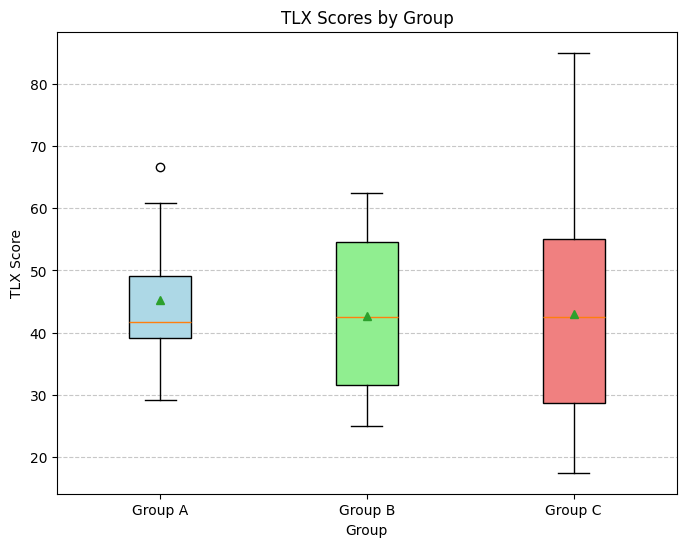

In [81]:
# Combine all groups into one dataset
all_data = pd.concat([group_a_tlx, group_b_tlx, group_c_tlx])
grand_mean = all_data.mean()

# Calculate Sum of Squares Between (SS_between)
n_a, n_b, n_c = len(group_a_tlx), len(group_b_tlx), len(group_c_tlx)
mean_a_tlx, mean_b_tlx, mean_c_tlx = group_a_tlx.mean(), group_b_tlx.mean(), group_c_tlx.mean()
SS_between_tlx = n_a * (mean_a_tlx - grand_mean)**2 + n_b * (mean_b_tlx - grand_mean)**2 + n_c * (mean_c_tlx - grand_mean)**2

# Calculate Sum of Squares Within (SS_within)
SS_within_tlx = sum((group_a_tlx - mean_a_tlx)**2) + sum((group_b_tlx - mean_b_tlx)**2) + sum((group_c_tlx - mean_c_tlx)**2)

# Calculate Total Sum of Squares (SS_total)
SS_total_tlx = SS_between_tlx + SS_within_tlx

# Calculate Eta Squared (η²)
eta_squared_tlx = SS_between_tlx / SS_total_tlx

# Print results
print("SS stands for Sum of Squares")
print(f"SS_between: {SS_between_tlx:.4f}")
print(f"SS_within: {SS_within_tlx:.4f}")
print(f"SS_total: {SS_total_tlx:.4f}")
print(f"Effect Size (Eta Squared, η²): {eta_squared_tlx:.4f}")

# Perform one-way ANOVA
stat, p = f_oneway(group_a_tlx, group_b_tlx, group_c_tlx)
print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")
if p < 0.05:
    print("There is a significant difference between the groups.")
else:
    print("No significant difference between the groups.")

# Plot the scores for each group
plt.figure(figsize=(8, 6))
data = [group_a_tlx, group_b_tlx, group_c_tlx]
boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)
plt.title("TLX Scores by Group")

# Assign different colors to each group
colors = ['lightblue', 'lightgreen', 'lightcoral']
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)

plt.ylabel("TLX Score")
plt.xlabel("Group")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Compaersing between groups for each individual messure

In [82]:
# Columns to test
columns_to_test = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level"]

# Initialize a list to store the results
results = []

for col in columns_to_test:
    print(f"\n### Testing for {col} ###")
    
    # Extract data for each group
    group_a = TLX_allScore[TLX_allScore["Group"] == "Group A"][col]
    group_b = TLX_allScore[TLX_allScore["Group"] == "Group B"][col]
    group_c = TLX_allScore[TLX_allScore["Group"] == "Group C"][col]
    
    # Check assumptions and decide the test
    test_type = testing_for_assumptions_by_group(TLX_allScore, score_col=col, group_col="Group")
    
    if test_type == 1:  # ANOVA
        print(f"Running ANOVA for {col}")
        stat, p = f_oneway(group_a, group_b, group_c)
        test_name = "ANOVA"
    elif test_type == 0:  # Kruskal-Wallis
        print(f"Running Kruskal-Wallis for {col}")
        stat, p = kruskal(group_a, group_b, group_c)
        test_name = "Kruskal-Wallis"
    else:
        print(f"Not enough data to test {col}.")
        results.append({"Column": col, "Test": "Not enough data", "p-value": None, "Significant": "No"})
        continue  # Skip to the next column if there's not enough data
    
    # Determine significance
    significant = "Yes" if p < 0.05 else "No"
    
    # Append the result to the list
    results.append({"Column": col, "Test": test_name, "p-value": p, "Significant": significant})
    
    # If p-value is less than 0.05, create a plot
    if p < 0.05:
        print(f"Significant result for {col} (p = {p:.4f}). Creating a plot...")
        
        # Combine data for plotting
        data = [group_a, group_b, group_c]
        labels = ["Group A", "Group B", "Group C"]
        
        # Create a boxplot
        plt.figure(figsize=(8, 6))
        boxplot = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True)
        
        # Assign colors to each group
        colors = ['lightblue', 'lightgreen', 'lightcoral']
        for patch, color in zip(boxplot['boxes'], colors):
            patch.set_facecolor(color)
        
        # Add plot title and labels
        plt.title(f"{col} by Group")
        plt.ylabel(col)
        plt.xlabel("Group")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Show the plot
        plt.show()

# Create a summary DataFrame
summary_df_tlx = pd.DataFrame(results)

# Display the summary DataFrame
print("\n### Summary of Findings ###")
print(summary_df_tlx )


### Testing for Mental Demand ###
# Testing assumptions for Mental Demand #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9311, p = 0.2833 → Data appears normal

Group Group B:
  ❌ Stat = 0.8740, p = 0.0386 → Data not normal

Group Group A:
  ❌ Stat = 0.8744, p = 0.0392 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.6710, p = 0.5166 → Variances are equal

# Final Group Comparison Test for Mental Demand #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 1.6170, p = 0.4455
Running Kruskal-Wallis for Mental Demand

### Testing for Physical Demand ###
# Testing assumptions for Physical Demand #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9077, p = 0.1247 → Data appears normal

Group Group B:
  ❌ Stat = 0.8754, p = 0.0406 → Data not normal

Group Group A:
  ✔️ Stat = 0.8881, p = 0.0629 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.2424, p = 0.7858 → V

## IEQ

In [83]:
questions_df = df_post.iloc[:, 8:39].copy()
questions_df = questions_df.apply(pd.to_numeric, errors='coerce')

questions_to_reverse_indices = [5, 7, 9, 17, 19]
for index in questions_to_reverse_indices:
    column_name = questions_df.columns[index]
    questions_df[column_name] = 8 - questions_df[column_name]

IEQ_scores_list = questions_df.sum(axis=1, skipna=True)
IEQ_scores = pd.DataFrame({
    "IEQ Score": IEQ_scores_list,
    "Participant Number": df_post.iloc[:, 6].values,
    "Group": df_post.iloc[:, 7].values,
    "Single Question Measure of Immersion": df_post.iloc[:, 39].values
})

omega_ieq = calculate_omega(questions_df)
print(f"The reliability of the IEQ was {interpret_omega(omega_ieq)}, with a McDonald's Omega (TLX combined) = {omega_ieq:.3f}")
IEQ_scores

The reliability of the IEQ was Good, with a McDonald's Omega (TLX combined) = 0.862


h:\GitHub\P8-Project\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,IEQ Score,Participant Number,Group,Single Question Measure of Immersion
0,173,1,Group C,7
1,137,2,Group C,6
2,161,3,Group B,10
3,163,4,Group C,7
4,172,5,Group C,9
5,161,6,Group B,8
6,171,7,Group A,7
7,159,8,Group C,9
8,166,9,Group B,8
9,167,10,Group B,7


In [84]:
IEQ_scores.describe()

,IEQ Score,Participant Number,Single Question Measure of Immersion
count,45.000000,45.000000,45.000000
mean,159.666667,22.777778,7.577778
std,16.517209,13.010291,1.252069
min,88.000000,1.000000,5.000000
25%,154.000000,12.000000,7.000000
50%,161.000000,23.000000,7.000000
75%,172.000000,33.000000,8.000000
max,184.000000,45.000000,10.000000


### Testing for assumption before cleaning IEQ

In [85]:
testing_for_assumptions_by_group(IEQ_scores, score_col="IEQ Score", group_col="Group")

# Testing assumptions for IEQ Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9177, p = 0.1776 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9661, p = 0.7971 → Data appears normal

Group Group A:
  ❌ Stat = 0.7903, p = 0.0028 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.6447, p = 0.5299 → Variances are equal

# Final Group Comparison Test for IEQ Score #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 5.9146, p = 0.0520


0

In [86]:
testing_for_assumptions_by_group(IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9138, p = 0.1550 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9351, p = 0.3250 → Data appears normal

Group Group A:
  ❌ Stat = 0.7714, p = 0.0016 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 1.6103, p = 0.2119 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 6.5601, p = 0.0376


0

### Describing the different groups

In [87]:
# Extract data for each group
group_a_ieq = IEQ_scores[IEQ_scores["Group"] == "Group A"]["IEQ Score"]
group_b_ieq = IEQ_scores[IEQ_scores["Group"] == "Group B"]["IEQ Score"]
group_c_ieq = IEQ_scores[IEQ_scores["Group"] == "Group C"]["IEQ Score"]

print("#Low fi group: ")
print(group_a_ieq.describe())

#Low fi group: 
count     15.000000
mean     155.866667
std       22.093524
min       88.000000
25%      149.500000
50%      161.000000
75%      169.500000
max      181.000000
Name: IEQ Score, dtype: float64


In [88]:
print("#Low mid group: ")
print(group_b_ieq.describe())

#Low mid group: 
count     15.000000
mean     156.466667
std       11.025080
min      137.000000
25%      147.000000
50%      158.000000
75%      163.500000
max      174.000000
Name: IEQ Score, dtype: float64


In [89]:
print("#Low hi group: ")
print(group_c_ieq.describe())

#Low hi group: 
count     15.000000
mean     166.666667
std       12.992672
min      137.000000
25%      160.000000
50%      172.000000
75%      176.500000
max      184.000000
Name: IEQ Score, dtype: float64


### IEQ anova test

SS stands for Sum of Squares
SS_between: 1105.2000
SS_within: 10898.8000
SS_total: 12004.0000
Effect Size (Eta Squared, η²): 0.0921
ANOVA Results: F-statistic = 2.1295, p-value = 0.1316
No significant difference between the groups.


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\1182566836.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


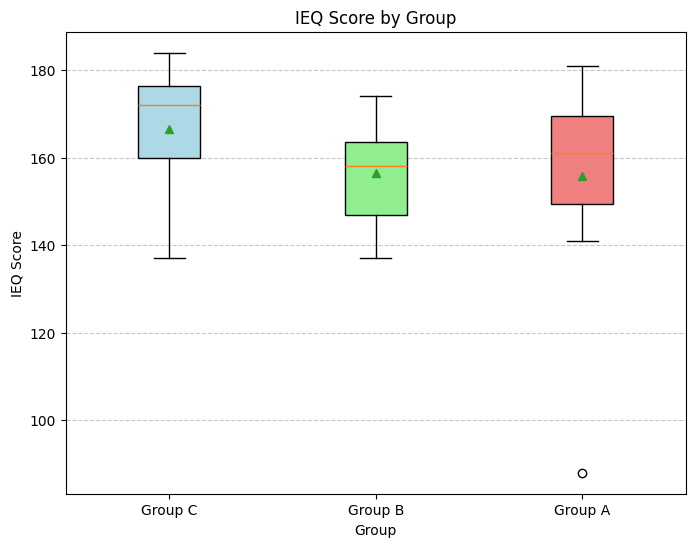

{'SS_between': np.float64(1105.1999999999969), 'SS_within': 10898.800000000001, 'SS_total': np.float64(12003.999999999998), 'eta_squared': np.float64(0.09206931022992311), 'anova_stat': np.float64(2.129518846111499), 'anova_p_value': np.float64(0.1315547769849901)}


In [90]:
results_IEQ = analyze_groups_anova(df=IEQ_scores, score_col="IEQ Score", group_col="Group")
print(results_IEQ)

### Other Comparsing of IEQ then normale anova

In [91]:
print("Welch's ANOVA Results")
pg.welch_anova(dv='IEQ Score', between='Group', data=IEQ_scores) 

Welch's ANOVA Results


,Source,ddof1,ddof2,F,p-unc,np2
0,Group,2,26.5221,2.931957,0.070731,0.092069


In [92]:
# Group A vs Group C
stat_ac, p_ac = ttest_ind(group_c_ieq, group_b_ieq, equal_var=True)  # Use equal_var=True if variances are equal
print(f"Group A vs Group C: t-statistic = {stat_ac:.4f}, one-tailed p-value = {p_ac:.4f}")
# Group A vs Group B
stat_bc, p_bc = ttest_ind(group_c_ieq, group_b_ieq, equal_var=True)
print(f"Group B vs Group C: t-statistic = {stat_bc:.4f}, one-tailed p-value = {p_bc:.4f}")

# Group A vs Group B
stat_bc, p_bc = ttest_ind(group_b_ieq, group_a_ieq, equal_var=True)
print(f"Group B vs Group A: t-statistic = {stat_bc:.4f}, one-tailed p-value = {p_bc:.4f}")


Group A vs Group C: t-statistic = 2.3183, one-tailed p-value = 0.0280
Group B vs Group C: t-statistic = 2.3183, one-tailed p-value = 0.0280
Group B vs Group A: t-statistic = 0.0941, one-tailed p-value = 0.9257


### Kruskal test on Single Question mesure of immersion between groups

In [93]:
testing_for_assumptions_by_group(IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9138, p = 0.1550 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9351, p = 0.3250 → Data appears normal

Group Group A:
  ❌ Stat = 0.7714, p = 0.0016 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 1.6103, p = 0.2119 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 6.5601, p = 0.0376


0

Kruskal-Wallis test statistic = 6.5601, p-value = 0.0376
There is a significant difference between the groups.


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\23711797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


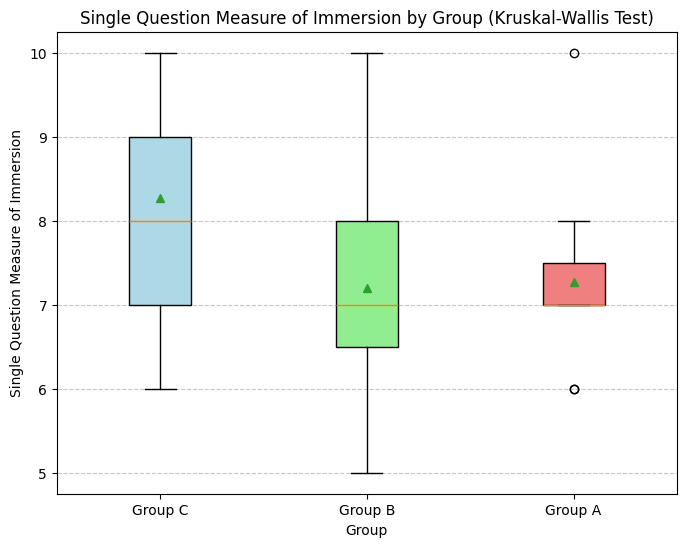

{'kruskal_stat': np.float64(6.5601155651859955), 'kruskal_p_value': np.float64(0.03762608261174385)}


In [94]:
results = analyze_kruskal_test(df=IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")
print(results)

In [95]:

group_descriptions = IEQ_scores.groupby("Group")[["IEQ Score", "Single Question Measure of Immersion"]].describe()
print(group_descriptions)

        IEQ Score                                                            \
            count        mean        std    min    25%    50%    75%    max   
Group                                                                         
Group A      15.0  155.866667  22.093524   88.0  149.5  161.0  169.5  181.0   
Group B      15.0  156.466667  11.025080  137.0  147.0  158.0  163.5  174.0   
Group C      15.0  166.666667  12.992672  137.0  160.0  172.0  176.5  184.0   

        Single Question Measure of Immersion                                \
                                       count      mean       std  min  25%   
Group                                                                        
Group A                                 15.0  7.266667  0.961150  6.0  7.0   
Group B                                 15.0  7.200000  1.264911  5.0  6.5   
Group C                                 15.0  8.266667  1.279881  6.0  7.0   

                         
         50%  75%   max  
Grou

### cleaning IEQ with single question immersion

In [96]:
threshold = 31 
singleQuestionScalingFactor = 21.7 # (217 - 31)/10

# Calculate the absolute difference between the Single Question score and the IEQ Score
IEQ_scores["Difference"] = abs(IEQ_scores["Single Question Measure of Immersion"] * 21.7 - IEQ_scores["IEQ Score"])

# Identify rows where the difference exceeds the threshold
outliers_df = IEQ_scores[IEQ_scores["Difference"] > threshold]

# Print the outliers
print("Outliers based on the difference between Single Question and IEQ Score:")
print(outliers_df)

# Optionally, drop the outliers from the original DataFrame
filtered_df = IEQ_scores[IEQ_scores["Difference"] <= threshold]
print(filtered_df.describe())
filtered_df

Outliers based on the difference between Single Question and IEQ Score:
    IEQ Score  Participant Number    Group  \
2         161                   3  Group B   
7         159                   8  Group C   
10        181                  11  Group A   
28        178                  29  Group C   
32        161                  33  Group C   
33        175                  34  Group C   
35         88                  36  Group A   
40        158                  41  Group B   

    Single Question Measure of Immersion  Difference  
2                                     10        56.0  
7                                      9        36.3  
10                                    10        36.0  
28                                    10        39.0  
32                                    10        56.0  
33                                    10        42.0  
35                                     7        63.9  
40                                     9        37.3  
        IEQ Score 

,IEQ Score,Participant Number,Group,Single Question Measure of Immersion,Difference
0,173,1,Group C,7,21.1
1,137,2,Group C,6,6.8
3,163,4,Group C,7,11.1
4,172,5,Group C,9,23.3
5,161,6,Group B,8,12.6
6,171,7,Group A,7,19.1
8,166,9,Group B,8,7.6
9,167,10,Group B,7,15.1
11,144,12,Group B,6,13.8
12,144,13,Group A,7,7.9


### Testing for Assuptions by groups 

In [97]:
testing_for_assumptions_by_group(filtered_df, score_col="IEQ Score", group_col="Group")

# Testing assumptions for IEQ Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9257, p = 0.3689 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9580, p = 0.7225 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9359, p = 0.4060 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.2736, p = 0.7623 → Variances are equal

# Final Group Comparison Test for IEQ Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 2.0421, p = 0.1454


1

In [98]:
testing_for_assumptions_by_group(filtered_df, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.8887, p = 0.1341 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8829, p = 0.0781 → Data appears normal

Group Group A:
  ❌ Stat = 0.7945, p = 0.0059 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 1.6275, p = 0.2114 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 4.7989, p = 0.0908


0

### Anova on IEQ score 

SS stands for Sum of Squares
SS_between: 624.9662
SS_within: 5202.6014
SS_total: 5827.5676
Effect Size (Eta Squared, η²): 0.1072
ANOVA Results: F-statistic = 2.0421, p-value = 0.1454
No significant difference between the groups.


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\1182566836.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


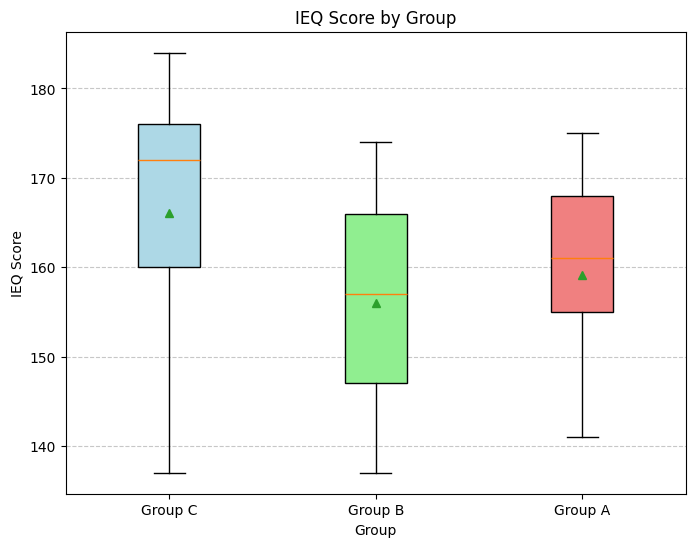

{'SS_between': np.float64(624.9661689661691), 'SS_within': 5202.601398601399, 'SS_total': np.float64(5827.5675675675675), 'eta_squared': np.float64(0.10724305839786781), 'anova_stat': np.float64(2.0421370115498396), 'anova_p_value': np.float64(0.1453667253403652)}


In [99]:
results_filterd_IEQ = analyze_groups_anova(df=filtered_df, score_col="IEQ Score", group_col="Group")
print(results_filterd_IEQ)

### Kruskal test on single question measure of immersion

Kruskal-Wallis test statistic = 4.7989, p-value = 0.0908
No significant difference between the groups.


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\23711797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


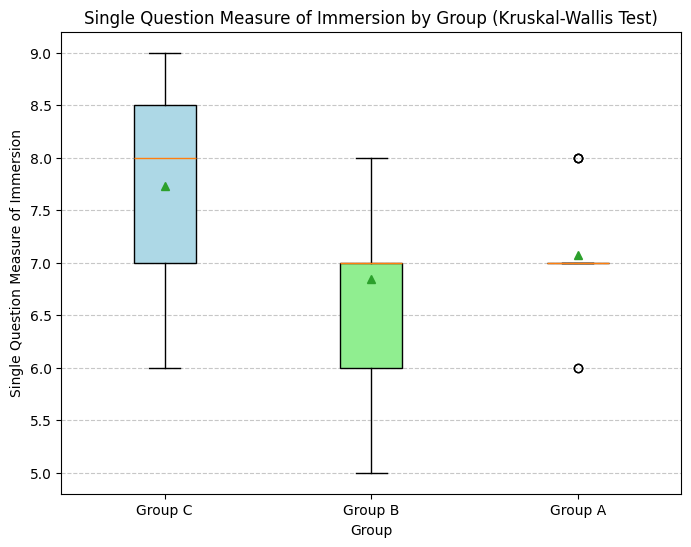

{'kruskal_stat': np.float64(4.798925212718322), 'kruskal_p_value': np.float64(0.0907667176422732)}


In [100]:
results = analyze_kruskal_test(df=filtered_df, score_col="Single Question Measure of Immersion", group_col="Group")
print(results)

In [101]:
group_descriptions = filtered_df.groupby("Group")[["IEQ Score", "Single Question Measure of Immersion"]].describe()
print(group_descriptions)

        IEQ Score                                                            \
            count        mean        std    min    25%    50%    75%    max   
Group                                                                         
Group A      13.0  159.153846  11.013977  141.0  155.0  161.0  168.0  175.0   
Group B      13.0  156.000000  11.818065  137.0  147.0  157.0  166.0  174.0   
Group C      11.0  166.090909  14.390654  137.0  160.0  172.0  176.0  184.0   

        Single Question Measure of Immersion                                \
                                       count      mean       std  min  25%   
Group                                                                        
Group A                                 13.0  7.076923  0.640513  6.0  7.0   
Group B                                 13.0  6.846154  0.898717  5.0  6.0   
Group C                                 11.0  7.727273  1.009050  6.0  7.0   

                        
         50%  75%  max  
Group 

## comparing between IEQ and TLX

In [102]:
# Merge the two DataFrames on the "Participant Number" column


merged_df = pd.merge(TLX_allScore, IEQ_scores, on="Participant Number", suffixes=("_TLX", "_IEQ"))
if len(merged_df["Group_IEQ"])> 45:
    # Remove rows where Group_IEQ and Group_TLX do not match
    merged_df = merged_df[merged_df["Group_IEQ"] == merged_df["Group_TLX"]].reset_index(drop=True)
print(len(TLX_allScore), len(IEQ_scores),len(merged_df["Group_IEQ"]))
merged_df

45 45 45


,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,Group_TLX,TLX Score,IEQ Score,Group_IEQ,Single Question Measure of Immersion,Difference
0,50,15,30,40,65,40,1,Group C,40.000000,173,Group C,7,21.1
1,70,30,25,85,80,45,2,Group C,55.833333,137,Group C,6,6.8
2,70,30,5,100,100,25,3,Group B,55.000000,161,Group B,10,56.0
3,30,25,15,10,60,5,4,Group C,24.166667,163,Group C,7,11.1
4,85,95,90,95,90,55,5,Group C,85.000000,172,Group C,9,23.3
5,30,35,25,15,40,30,6,Group B,29.166667,161,Group B,8,12.6
6,65,35,75,90,85,50,7,Group A,66.666667,171,Group A,7,19.1
7,50,5,40,70,30,5,8,Group C,33.333333,159,Group C,9,36.3
8,25,10,5,90,20,70,9,Group B,36.666667,166,Group B,8,7.6
9,30,20,15,85,20,20,10,Group B,31.666667,167,Group B,7,15.1


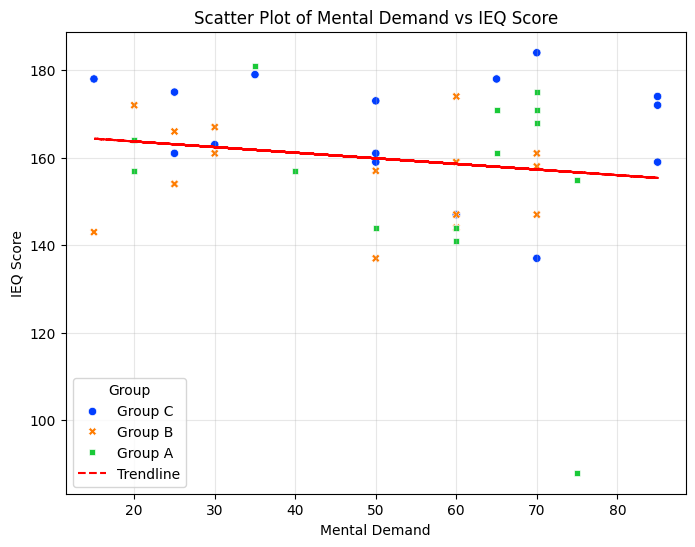

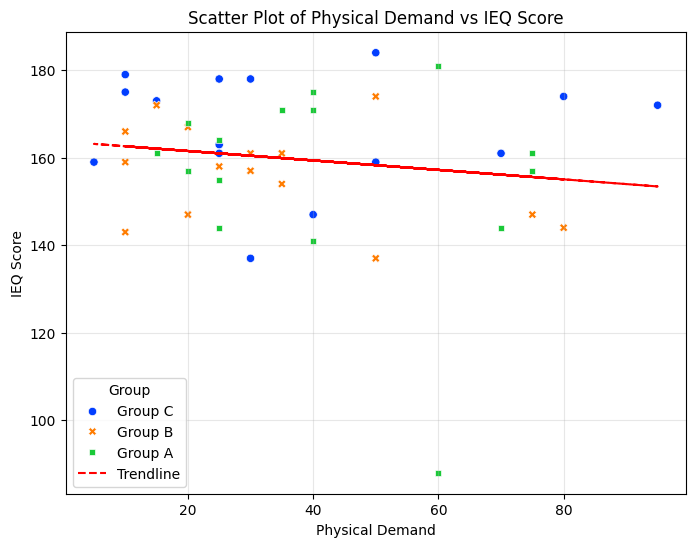

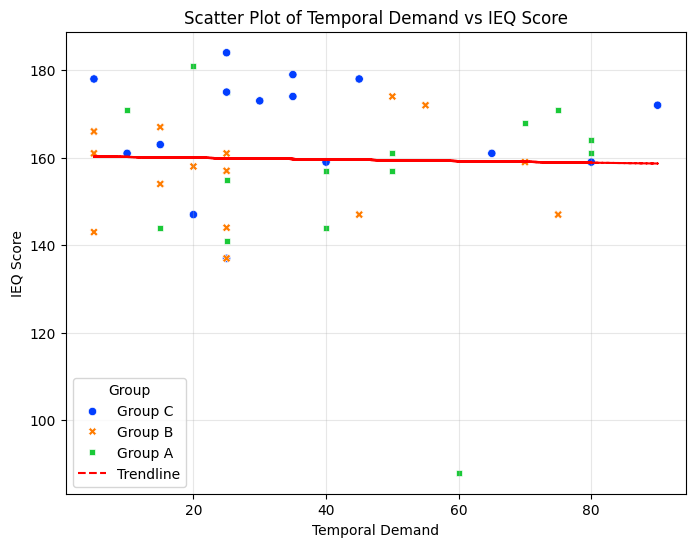

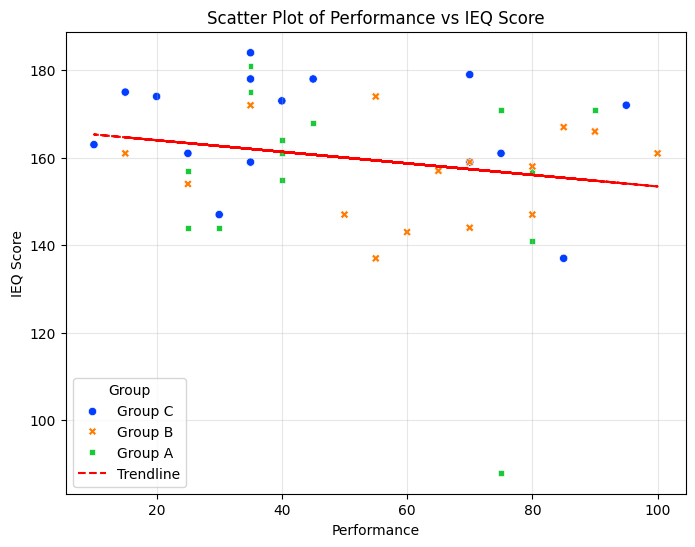

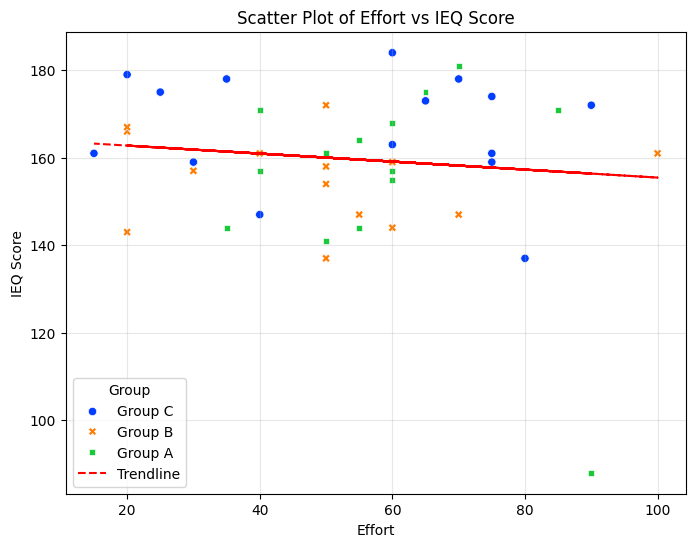

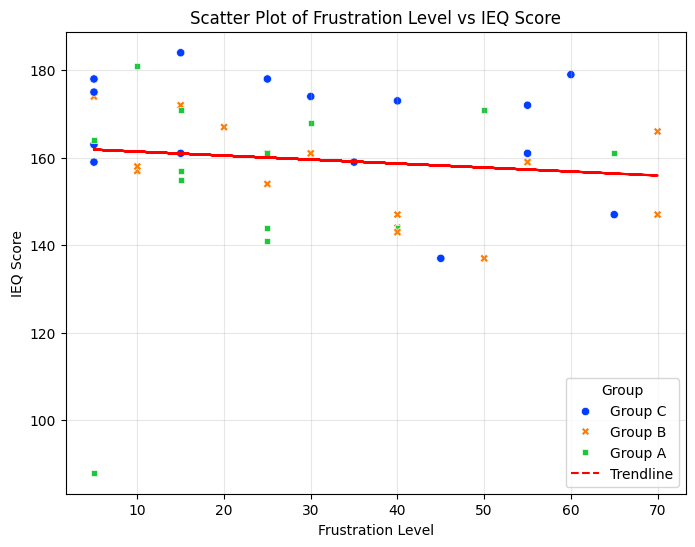

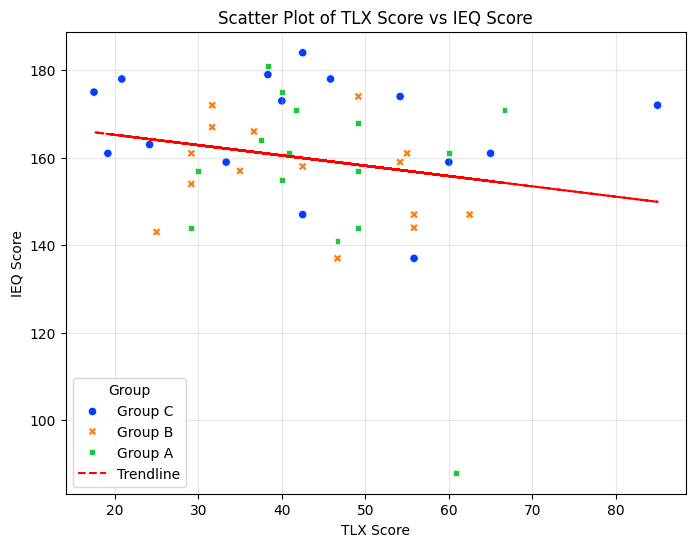

In [103]:
# List of columns to compare with IEQ Score
columns_to_compare = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level", "TLX Score"]

for col in columns_to_compare:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=merged_df[col],
        y=merged_df["IEQ Score"],
        hue=merged_df["Group_IEQ"],
        palette="bright",
        style=merged_df["Group_IEQ"]
    )
    
    # Add a trendline
    z = np.polyfit(merged_df[col], merged_df["IEQ Score"], 1)
    p = np.poly1d(z)
    plt.plot(merged_df[col], p(merged_df[col]), color="red", linestyle="--", label="Trendline")
    
    # Add labels, title, and legend
    plt.xlabel(col)
    plt.ylabel("IEQ Score")
    plt.title(f"Scatter Plot of {col} vs IEQ Score")
    plt.legend(title="Group")
    plt.grid(alpha=0.3)
    plt.show()

## Summerize stiff

In [104]:
# Summarize Performance and TLX Score by group
performance_tlx_summary = merged_df.groupby("Group_TLX").agg(
    Performance_Min=("Performance", "min"),
    Performance_Max=("Performance", "max"),
    Performance_Mean=("Performance", "mean"),
    Performance_Std=("Performance", "std"),
    TLX_Min=("TLX Score", "min"),
    TLX_Max=("TLX Score", "max"),
    TLX_Mean=("TLX Score", "mean"),
    TLX_Std=("TLX Score", "std")
).reset_index()

print(performance_tlx_summary)
print_out_latex_from_dataframe(summary_df_tlx, name="TLX Subclass significant different Summary")
print_out_latex_from_dataframe(performance_tlx_summary, name="TLX Performance Summary")

  Group_TLX  Performance_Min  Performance_Max  Performance_Mean  \
0   Group A               25               90         50.333333   
1   Group B               15              100         62.333333   
2   Group C               10               95         45.666667   

   Performance_Std    TLX_Min    TLX_Max   TLX_Mean    TLX_Std  
0        22.635833  29.166667  66.666667  45.277778  10.868380  
1        24.043611  25.000000  62.500000  42.666667  12.236103  
2        26.650293  17.500000  85.000000  42.944444  18.942443  
\begin{figure}
\centering
\begin{tabular}{llrl}
\toprule
Column & Test & P Value & Significant \\
\midrule
Mental Demand & Kruskal-Wallis & 0.45 & No \\
Physical Demand & Kruskal-Wallis & 0.51 & No \\
Temporal Demand & ANOVA & 0.30 & No \\
Performance & Kruskal-Wallis & 0.18 & No \\
Effort & ANOVA & 0.61 & No \\
Frustration Level & Kruskal-Wallis & 0.32 & No \\
\bottomrule
\end{tabular}

\caption{A table showing the TLX Subclass significant different Summary with the

# Test subjects general infomation

In [105]:
merged_df["Group_TLX"]

0     Group C
1     Group C
2     Group B
3     Group C
4     Group C
5     Group B
6     Group A
7     Group C
8     Group B
9     Group B
10    Group A
11    Group B
12    Group A
13    Group B
14    Group A
15    Group A
16    Group A
17    Group C
18    Group B
19    Group A
20    Group C
21    Group B
22    Group C
23    Group C
24    Group A
25    Group B
26    Group B
27    Group A
28    Group C
29    Group C
30    Group C
31    Group A
32    Group C
33    Group C
34    Group B
35    Group A
36    Group A
37    Group A
38    Group A
39    Group B
40    Group B
41    Group B
42    Group A
43    Group B
44    Group C
Name: Group_TLX, dtype: object

In [106]:
print(merged_df.describe())

vr_experience_df = merged_df[["Participant Number", "Group_IEQ"]].copy()
vr_experience_df["VR Experience"] = df.iloc[:, 9].values
vr_experience_df["Bartending Experience"] = df.iloc[:, 10].values
vr_experience_df["Affect your heart rate?"]= df.iloc[:, 11].values
vr_experience_df.rename(columns={
    "Group_IEQ": "Group",
}, inplace=True)

vr_experience_df

# None = 1 , A little = 2, Medium = 3, Quite a bit = 4, A lot = 5

       Mental Demand  Physical Demand  Temporal Demand  Performance  \
count      45.000000        45.000000        45.000000    45.000000   
mean       51.555556        37.333333        37.111111    52.777778   
std        20.665689        23.272106        24.108865    24.967150   
min        15.000000         5.000000         5.000000    10.000000   
25%        30.000000        20.000000        20.000000    35.000000   
50%        60.000000        30.000000        25.000000    45.000000   
75%        70.000000        50.000000        50.000000    75.000000   
max        85.000000        95.000000        90.000000   100.000000   

           Effort  Frustration Level  Participant Number  TLX Score  \
count   45.000000          45.000000           45.000000  45.000000   
mean    54.000000          29.000000           22.777778  43.629630   
std     20.851204          20.298903           13.010291  14.170182   
min     15.000000           5.000000            1.000000  17.500000   
25%  

,Participant Number,Group,VR Experience,Bartending Experience,Affect your heart rate?
0,1,Group C,A lot,NaN,Minor heart condition;
1,2,Group C,Medium,Quite a bit,Caffeine;
2,3,Group B,Medium,Medium,Matcha;
3,4,Group C,A little,NaN,None;
4,5,Group C,Quite a bit,A little,Caffeine;
5,6,Group B,A little,NaN,None;
6,7,Group A,A little,Medium,Caffeine;
7,8,Group C,A little,NaN,Caffeine;
8,9,Group B,A little,NaN,None;
9,10,Group B,NaN,Medium,Caffeine;


PRoblem with none answeres

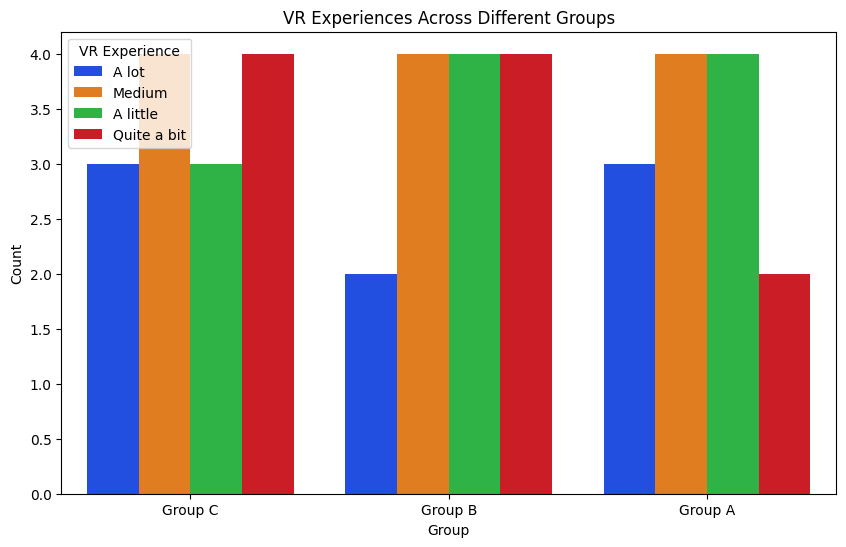

In [107]:
# Create a count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=vr_experience_df, x="Group", hue="VR Experience", palette="bright")
plt.title("VR Experiences Across Different Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="VR Experience")
plt.show()

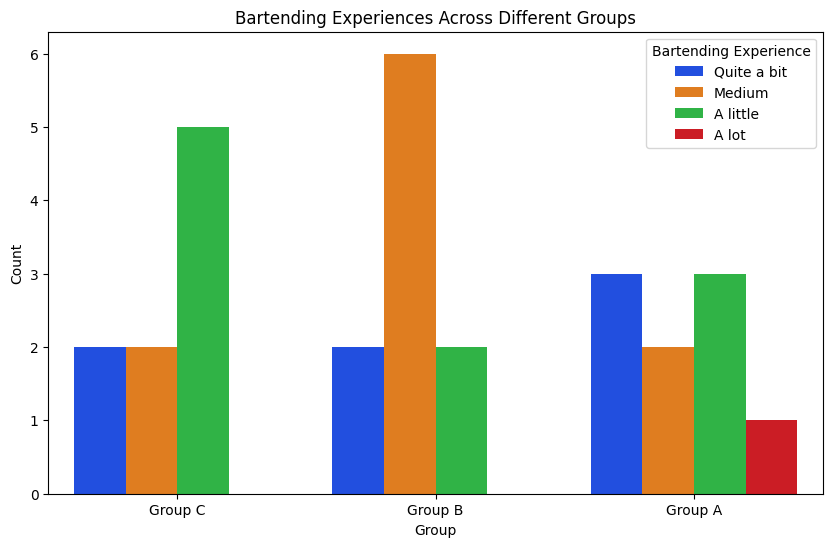

In [108]:
plt.figure(figsize=(10, 6))
sns.countplot(data=vr_experience_df, x="Group", hue="Bartending Experience", palette="bright")
plt.title("Bartending Experiences Across Different Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="Bartending Experience")
plt.show()

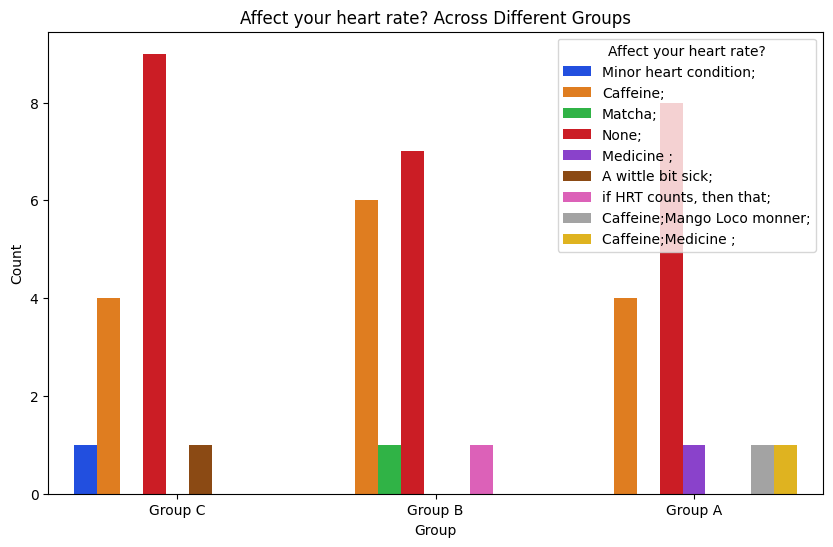

In [109]:
plt.figure(figsize=(10, 6))
sns.countplot(data=vr_experience_df, x="Group", hue="Affect your heart rate?", palette="bright")
plt.title("Affect your heart rate? Across Different Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="Affect your heart rate?")
plt.show()

# Latex output

In [110]:
# Columns to summarize
nasatlx_columns = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level"]

# Initialize an empty list to store the summary
nasatlx_summary = []

# Loop through each column and calculate statistics
for col in nasatlx_columns:
    for group in merged_df["Group_TLX"].unique():
        group_data = merged_df[merged_df["Group_TLX"] == group][col]
        nasatlx_summary.append({
            "Dimension": col,
            "Group": group,
            "Mean": group_data.mean(),
            "Std Dev": group_data.std(),
            "Min": group_data.min(),
            "Max": group_data.max()
        })

# Convert the summary into a DataFrame
nasatlx_summary_df = pd.DataFrame(nasatlx_summary)

nasatlx_summary_df

,Dimension,Group,Mean,Std Dev,Min,Max
0,Mental Demand,Group C,53.333333,23.502786,15,85
1,Mental Demand,Group B,46.333333,19.952324,15,70
2,Mental Demand,Group A,55.000000,18.612592,20,75
3,Physical Demand,Group C,37.333333,26.916980,5,95
4,Physical Demand,Group B,33.000000,22.184293,10,80
5,Physical Demand,Group A,41.666667,21.100666,15,75
6,Temporal Demand,Group C,36.333333,24.674066,5,90
7,Temporal Demand,Group B,30.666667,22.980323,5,75
8,Temporal Demand,Group A,44.333333,24.265398,10,80
9,Performance,Group C,45.666667,26.650293,10,95


In [111]:
def print_out_latex_from_pd(pd, name):
    Header = pd.columns.tolist()
    stringheader = ",".join(Header)
    print("\\begin{figure}\n",
          "\\centering\n",
          f"{pd.to_latex(index=False, float_format='%.2f', escape=False)}\n",
          "\\caption{","A table showing the",name," With the headers: ",stringheader,"}\n",
          f"\\label{{tab-{name}}}\n",
          "\\end{figure}\n")

In [112]:
print_out_latex_from_pd(nasatlx_summary_df, "Nasa-TLX-Scores")

\begin{figure}
 \centering
 \begin{tabular}{llrrrr}
\toprule
Dimension & Group & Mean & Std Dev & Min & Max \\
\midrule
Mental Demand & Group C & 53.33 & 23.50 & 15 & 85 \\
Mental Demand & Group B & 46.33 & 19.95 & 15 & 70 \\
Mental Demand & Group A & 55.00 & 18.61 & 20 & 75 \\
Physical Demand & Group C & 37.33 & 26.92 & 5 & 95 \\
Physical Demand & Group B & 33.00 & 22.18 & 10 & 80 \\
Physical Demand & Group A & 41.67 & 21.10 & 15 & 75 \\
Temporal Demand & Group C & 36.33 & 24.67 & 5 & 90 \\
Temporal Demand & Group B & 30.67 & 22.98 & 5 & 75 \\
Temporal Demand & Group A & 44.33 & 24.27 & 10 & 80 \\
Performance & Group C & 45.67 & 26.65 & 10 & 95 \\
Performance & Group B & 62.33 & 24.04 & 15 & 100 \\
Performance & Group A & 50.33 & 22.64 & 25 & 90 \\
Effort & Group C & 54.33 & 24.49 & 15 & 90 \\
Effort & Group B & 50.00 & 22.28 & 20 & 100 \\
Effort & Group A & 57.67 & 15.45 & 35 & 90 \\
Frustration Level & Group C & 30.67 & 21.87 & 5 & 65 \\
Frustration Level & Group B & 33.67 & 20.91 &

In [113]:
print_out_latex_from_pd(summary_df_tlx, "TLX-Scores-ANOVA-Kruskal-Wallis")

\begin{figure}
 \centering
 \begin{tabular}{llrl}
\toprule
Column & Test & p-value & Significant \\
\midrule
Mental Demand & Kruskal-Wallis & 0.45 & No \\
Physical Demand & Kruskal-Wallis & 0.51 & No \\
Temporal Demand & ANOVA & 0.30 & No \\
Performance & Kruskal-Wallis & 0.18 & No \\
Effort & ANOVA & 0.61 & No \\
Frustration Level & Kruskal-Wallis & 0.32 & No \\
\bottomrule
\end{tabular}

 \caption{ A table showing the TLX-Scores-ANOVA-Kruskal-Wallis  With the headers:  Column,Test,p-value,Significant }
 \label{tab-TLX-Scores-ANOVA-Kruskal-Wallis}
 \end{figure}



In [114]:
# Summarize IEQ scores by group
ieq_summary_by_group = filtered_df.groupby("Group")["IEQ Score"].agg(
    Mean="mean",
    Std_Dev="std",
    Min="min",
    Max="max",
    Count="count"
).reset_index()

# Summarize Single Question Measure of Immersion by group
single_question_summary_by_group = filtered_df.groupby("Group")["Single Question Measure of Immersion"].agg(
    Mean="mean",
    Std_Dev="std",
    Min="min",
    Max="max",
    Count="count"
).reset_index()

# Summarize the differences between IEQ Score and Single Question Measure of Immersion by group
difference_summary_by_group = filtered_df.groupby("Group")["Difference"].agg(
    Mean="mean",
    Std_Dev="std",
    Min="min",
    Max="max",
    Count="count"
).reset_index()

# Display the summaries
print("### IEQ Score Summary by Group ###")
print(ieq_summary_by_group)

print("\n### Single Question Measure of Immersion Summary by Group ###")
print(single_question_summary_by_group)

print("\n### Difference Summary by Group ###")
# Perform one-way ANOVA on the differences
stat, p = f_oneway(
    filtered_df[filtered_df["Group"] == "Group A"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group B"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group C"]["Difference"]
)
print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")

# Perform t-tests between groups for the differences
stat_ab, p_ab = ttest_ind(
    filtered_df[filtered_df["Group"] == "Group A"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group B"]["Difference"],
    equal_var=True
)
stat_ac, p_ac = ttest_ind(
    filtered_df[filtered_df["Group"] == "Group A"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group C"]["Difference"],
    equal_var=True
)
stat_bc, p_bc = ttest_ind(
    filtered_df[filtered_df["Group"] == "Group B"]["Difference"],
    filtered_df[filtered_df["Group"] == "Group C"]["Difference"],
    equal_var=True
)

print(f"T-test Group A vs Group B: t-statistic = {stat_ab:.4f}, p-value = {p_ab:.4f}")
print(f"T-test Group A vs Group C: t-statistic = {stat_ac:.4f}, p-value = {p_ac:.4f}")
print(f"T-test Group B vs Group C: t-statistic = {stat_bc:.4f}, p-value = {p_bc:.4f}")

# Display the cleaned summary
# Perform one-way ANOVA on the non-cleaned IEQ data
stat_ieq, p_ieq = f_oneway(
    IEQ_scores[IEQ_scores["Group"] == "Group A"]["IEQ Score"],
    IEQ_scores[IEQ_scores["Group"] == "Group B"]["IEQ Score"],
    IEQ_scores[IEQ_scores["Group"] == "Group C"]["IEQ Score"]
)
print(f"ANOVA on non-cleaned IEQ data: F-statistic = {stat_ieq:.4f}, p-value = {p_ieq:.4f}")

# Display the cleaned summary
# Convert the summaries into data frames for better visualization and further analysis
ieq_summary_df = pd.DataFrame(ieq_summary_by_group)
single_question_summary_df = pd.DataFrame(single_question_summary_by_group)
difference_summary_df = pd.DataFrame(difference_summary_by_group)

# Display the data frames
print("### IEQ Score Summary by Group (DataFrame) ###")
print(ieq_summary_df)

print("\n### Single Question Measure of Immersion Summary by Group (DataFrame) ###")
print(single_question_summary_df)

print("\n### Difference Summary by Group (DataFrame) ###")
# Collect all ANOVA 
# findings into a list
anova_findings = [
    {"Test": "ANOVA on Differences", "F-statistic": stat, "p-value": p},
    {"Test": "ANOVA on Non-Cleaned IEQ Data", "F-statistic": stat_ieq, "p-value": p_ieq},
    {"Test": "ANOVA on Filtered IEQ Data", "F-statistic": results_filterd_IEQ["anova_stat"], "p-value": results_filterd_IEQ["anova_p_value"]}
]

# Convert the findings into a DataFrame
anova_findings_df = pd.DataFrame(anova_findings)

# Display the DataFrame
print("### ANOVA Findings ###")
print(anova_findings_df)

# Perform Kruskal-Wallis test on Single Question Measure of Immersion

kruskal_stat, kruskal_p = kruskal(
    filtered_df[filtered_df["Group"] == "Group A"]["Single Question Measure of Immersion"],
    filtered_df[filtered_df["Group"] == "Group B"]["Single Question Measure of Immersion"],
    filtered_df[filtered_df["Group"] == "Group C"]["Single Question Measure of Immersion"]
)

# Add Kruskal-Wallis findings to the table
kruskal_findings = {
    "Test": "Kruskal-Wallis on Single Question Measure of Immersion",
    "H-statistic": kruskal_stat,
    "p-value": kruskal_p
}

# Convert findings to DataFrame for better visualization
kruskal_findings_df = pd.DataFrame([kruskal_findings])

# Display the findings
print("### Kruskal-Wallis Findings on Single Question Measure of Immersion ###")
print(kruskal_findings_df)


### IEQ Score Summary by Group ###
     Group        Mean    Std_Dev  Min  Max  Count
0  Group A  159.153846  11.013977  141  175     13
1  Group B  156.000000  11.818065  137  174     13
2  Group C  166.090909  14.390654  137  184     11

### Single Question Measure of Immersion Summary by Group ###
     Group      Mean   Std_Dev  Min  Max  Count
0  Group A  7.076923  0.640513    6    8     13
1  Group B  6.846154  0.898717    5    8     13
2  Group C  7.727273  1.009050    6    9     11

### Difference Summary by Group ###
ANOVA Results: F-statistic = 0.6598, p-value = 0.5234
T-test Group A vs Group B: t-statistic = 0.6877, p-value = 0.4982
T-test Group A vs Group C: t-statistic = 1.2071, p-value = 0.2402
T-test Group B vs Group C: t-statistic = 0.4317, p-value = 0.6702
ANOVA on non-cleaned IEQ data: F-statistic = 2.1295, p-value = 0.1316
### IEQ Score Summary by Group (DataFrame) ###
     Group        Mean    Std_Dev  Min  Max  Count
0  Group A  159.153846  11.013977  141  175     1

In [115]:
print_out_latex_from_pd(ieq_summary_df, "IEQ-Score-Summary-by-Group")
print_out_latex_from_pd(single_question_summary_df, "Single-Question-Measure-of-Immersion-Summary-by-Group")
print_out_latex_from_pd(difference_summary_df, "Difference-Summary-by-Group")
print_out_latex_from_pd(anova_findings_df, "ANOVA-Findings")
print_out_latex_from_pd(kruskal_findings_df, "Kruskal Wallis Findings on single question measure of immersion")


\begin{figure}
 \centering
 \begin{tabular}{lrrrrr}
\toprule
Group & Mean & Std_Dev & Min & Max & Count \\
\midrule
Group A & 159.15 & 11.01 & 141 & 175 & 13 \\
Group B & 156.00 & 11.82 & 137 & 174 & 13 \\
Group C & 166.09 & 14.39 & 137 & 184 & 11 \\
\bottomrule
\end{tabular}

 \caption{ A table showing the IEQ-Score-Summary-by-Group  With the headers:  Group,Mean,Std_Dev,Min,Max,Count }
 \label{tab-IEQ-Score-Summary-by-Group}
 \end{figure}

\begin{figure}
 \centering
 \begin{tabular}{lrrrrr}
\toprule
Group & Mean & Std_Dev & Min & Max & Count \\
\midrule
Group A & 7.08 & 0.64 & 6 & 8 & 13 \\
Group B & 6.85 & 0.90 & 5 & 8 & 13 \\
Group C & 7.73 & 1.01 & 6 & 9 & 11 \\
\bottomrule
\end{tabular}

 \caption{ A table showing the Single-Question-Measure-of-Immersion-Summary-by-Group  With the headers:  Group,Mean,Std_Dev,Min,Max,Count }
 \label{tab-Single-Question-Measure-of-Immersion-Summary-by-Group}
 \end{figure}

\begin{figure}
 \centering
 \begin{tabular}{lrrrrr}
\toprule
Group & Mean &

# Figures for the different messurement

In [116]:
# Replace group names in all relevant DataFrames
group_name_map = {"Group A": "Low", "Group B": "Medium", "Group C": "High"}

# IEQ_scores
IEQ_scores["Group"] = IEQ_scores["Group"].replace(group_name_map)
if "Group_IEQ" in IEQ_scores.columns:
    IEQ_scores["Group_IEQ"] = IEQ_scores["Group_IEQ"].replace(group_name_map)

# filtered_df
filtered_df["Group"] = filtered_df["Group"].replace(group_name_map)

# TLX_allScore
TLX_allScore["Group"] = TLX_allScore["Group"].replace(group_name_map)
if "Group_TLX" in TLX_allScore.columns:
    TLX_allScore["Group_TLX"] = TLX_allScore["Group_TLX"].replace(group_name_map)

# merged_df
if "Group_IEQ" in merged_df.columns:
    merged_df["Group_IEQ"] = merged_df["Group_IEQ"].replace(group_name_map)
if "Group_TLX" in merged_df.columns:
    merged_df["Group_TLX"] = merged_df["Group_TLX"].replace(group_name_map)

# vr_experience_df
vr_experience_df["Group"] = vr_experience_df["Group"].replace(group_name_map)

# Update other summary DataFrames if needed
ieq_summary_by_group["Group"] = ieq_summary_by_group["Group"].replace(group_name_map)
single_question_summary_by_group["Group"] = single_question_summary_by_group["Group"].replace(group_name_map)
difference_summary_by_group["Group"] = difference_summary_by_group["Group"].replace(group_name_map)



C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\2283636726.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Group"] = filtered_df["Group"].replace(group_name_map)


In [117]:
sns.set_theme(style="whitegrid")
custom_SNS_pallette = ["#E00015", "#00E034", "#2A2296", "#00E0B3", "#8B2E37", "#D500E0"]

C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\65797475.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=IEQ_scores, x="Group", y="IEQ Score", order=order, palette=["lightblue", "lightgreen", "lightcoral"], showmeans=True)


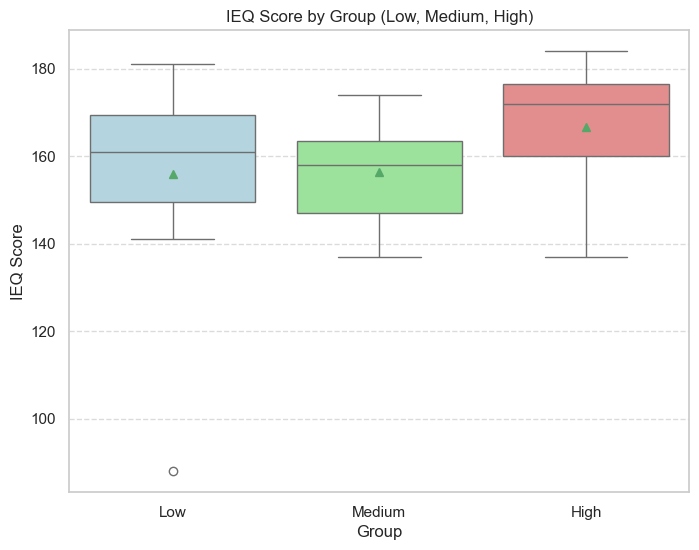

In [118]:
# Boxplot of IEQ Score by Group (A, B, C order)
plt.figure(figsize=(8, 6))
order = ["Low", "Medium", "High"]
sns.boxplot(data=IEQ_scores, x="Group", y="IEQ Score", order=order, palette=["lightblue", "lightgreen", "lightcoral"], showmeans=True)
plt.title("IEQ Score by Group (Low, Medium, High)")
plt.xlabel("Group")
plt.ylabel("IEQ Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\971436190.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


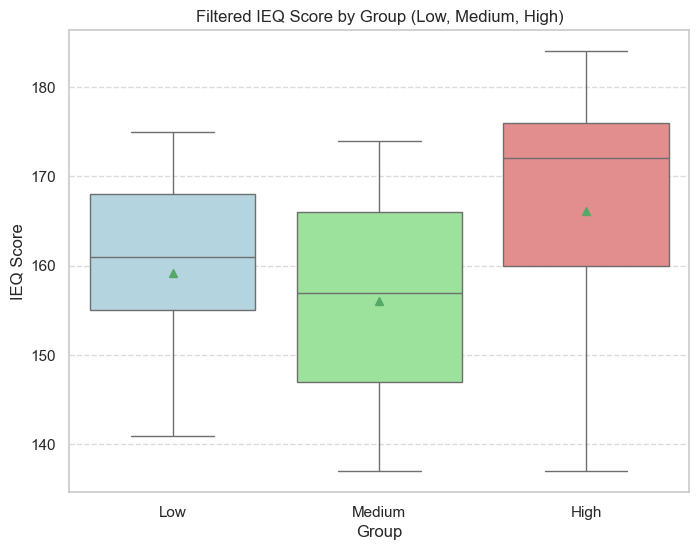

In [119]:
plt.figure(figsize=(8, 6))

# Boxplot of Filtered IEQ scores by Group (A, B, C order)
sns.boxplot(
	data=filtered_df,
	x="Group",
	y="IEQ Score",
	order=["Low", "Medium", "High"],  # Use full group names as in your DataFrame
	palette=["lightblue", "lightgreen", "lightcoral"],
	showmeans=True
)
plt.title("Filtered IEQ Score by Group (Low, Medium, High)")
plt.xlabel("Group")
plt.ylabel("IEQ Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [120]:
# add a new column (Filter = Filtered) to the filtered DataFrame
filtered_df["Filter"] = "Filtered"

# add a new column (Filter = Combined) to the original DataFrame
IEQ_scores["Filter"] = "Original"

combined_IEQ_Filter_df = pd.merge(
    filtered_df,
    IEQ_scores,
)

C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\2329584613.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Filter"] = "Filtered"


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\3133781884.py:5: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(


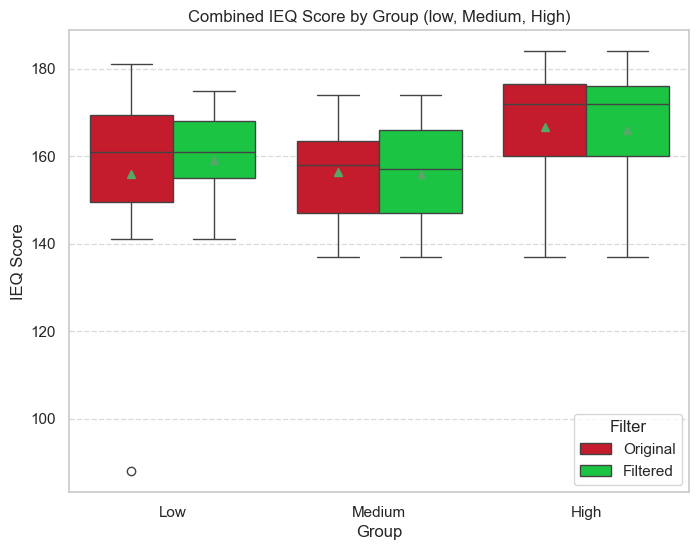

In [121]:
# Combine filterd IEQ scores and original IEQ scores for boxplot
combined_df = pd.concat([filtered_df, IEQ_scores], ignore_index=True)
# Boxplot of Combined IEQ scores by Group (A, B, C order)
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=combined_df,
    x="Group",
    y="IEQ Score",
    order=["Low", "Medium", "High"],  # Use full group names as in your DataFrame
    palette=custom_SNS_pallette,
    hue=combined_df["Filter"],
    hue_order=["Original", "Filtered"],  # Order of the hue categories
    showmeans=True
)
plt.title("Combined IEQ Score by Group (low, Medium, High)")
plt.xlabel("Group")
plt.ylabel("IEQ Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\1067143702.py:8: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(
C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\1067143702.py:27: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(


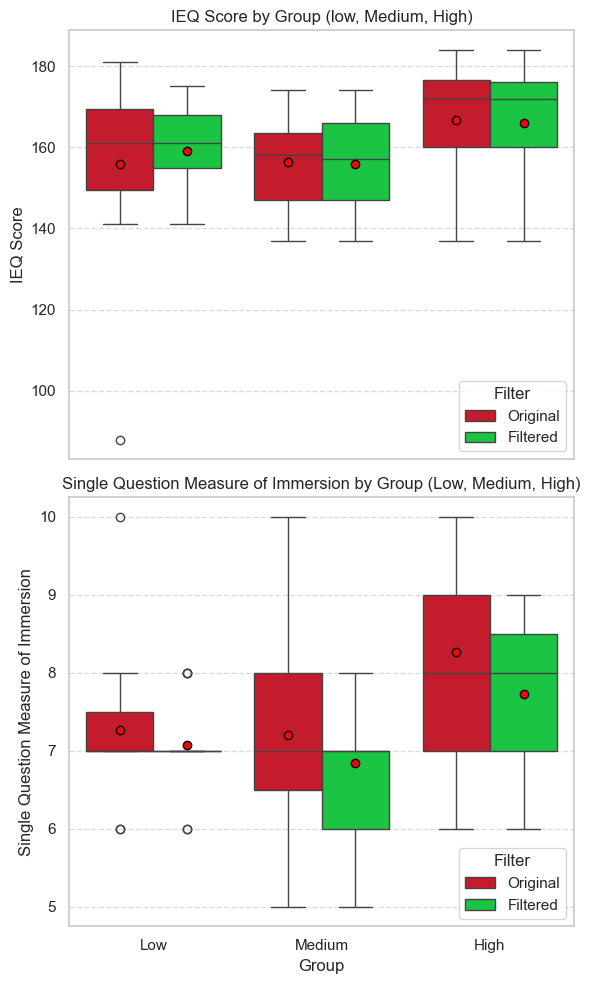

In [122]:
# Plot both IEQ Score and Single Question Measure of Immersion in the same figure (side by side)
fig, axes = plt.subplots(2, 1, figsize=(6, 10), sharex=True)

order = ["Low", "Medium", "High"]
hue_order = ["Original", "Filtered"]

# IEQ Score boxplot
sns.boxplot(
    data=combined_df,
    x="Group",
    y="IEQ Score",
    order=order,
    palette=custom_SNS_pallette,
    hue="Filter",
    hue_order=hue_order,
    showmeans="red",
      meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"},
    ax=axes[0]
)
axes[0].set_title("IEQ Score by Group (low, Medium, High)")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("IEQ Score")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title="Filter", loc="lower right")

# Single Question Measure of Immersion boxplot
sns.boxplot(
    data=combined_df,
    x="Group",
    y="Single Question Measure of Immersion",
    order=order,
    palette=custom_SNS_pallette,
    hue="Filter",
    hue_order=hue_order,
    showmeans="red", 
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"},
    ax=axes[1]
)
axes[1].set_title("Single Question Measure of Immersion by Group (Low, Medium, High)")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Single Question Measure of Immersion")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title="Filter", loc="lower right")

plt.tight_layout()
plt.show()


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\2667323816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=TLX_allScore, x="Group", y="TLX Score", order=order, palette=custom_SNS_pallette, showmeans="red", meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})
C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\2667323816.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(data=TLX_allScore, x="Group", y="TLX Score", order=order, palette=custom_SNS_pallette, showmeans="red", meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})


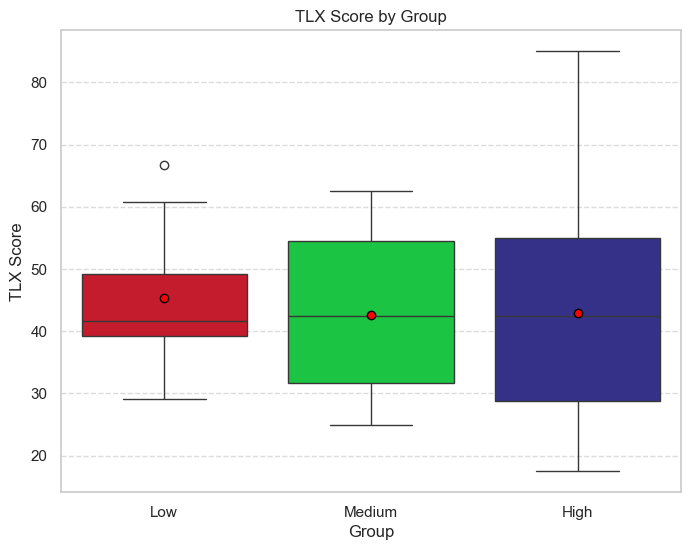

In [123]:
plt.figure(figsize=(8, 6))
order = ["Low", "Medium", "High"]
sns.boxplot(data=TLX_allScore, x="Group", y="TLX Score", order=order, palette=custom_SNS_pallette, showmeans="red", meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})
plt.title("TLX Score by Group")
plt.xlabel("Group")
plt.ylabel("TLX Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\3103224255.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=TLX_allScore, x="Group", y="Performance", order=order, palette=custom_SNS_pallette, showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})
C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\3103224255.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(data=TLX_allScore, x="Group", y="Performance", order=order, palette=custom_SNS_pallette, showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})


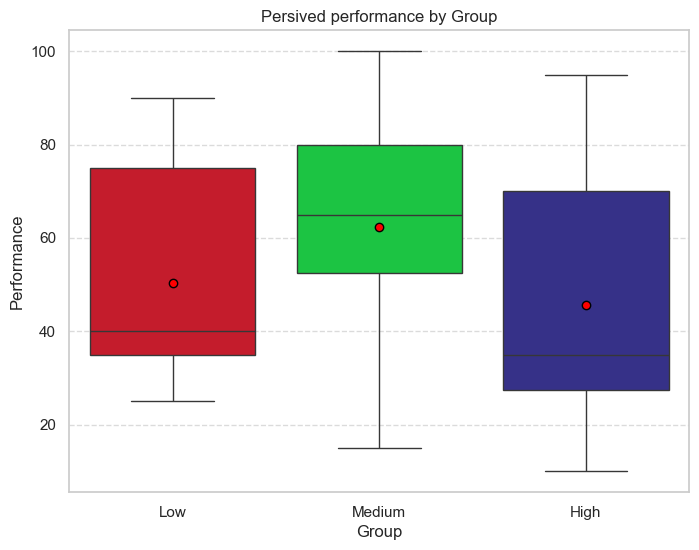

In [124]:
plt.figure(figsize=(8, 6))
order = ["Low", "Medium", "High"]
sns.boxplot(data=TLX_allScore, x="Group", y="Performance", order=order, palette=custom_SNS_pallette, showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})
plt.title("Persived performance by Group")
plt.xlabel("Group")
plt.ylabel("Performance")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\1450435492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\1450435492.py:4: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(


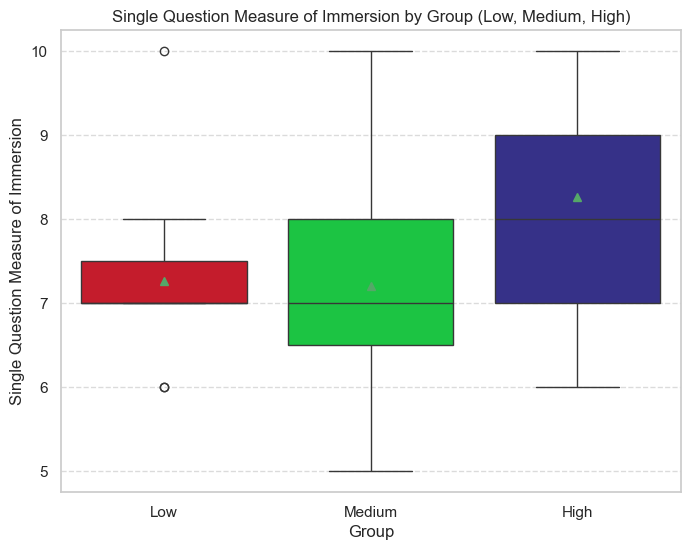

In [125]:
# Boxplot of Single Question Measure of Immersion by Group (A, B, C order)
plt.figure(figsize=(8, 6))
order = ["Low", "Medium", "High"]
sns.boxplot(
    data=IEQ_scores,
    x="Group",
    y="Single Question Measure of Immersion",
    order=order,
    palette=custom_SNS_pallette,
    showmeans=True
)
plt.title("Single Question Measure of Immersion by Group (Low, Medium, High)")
plt.xlabel("Group")
plt.ylabel("Single Question Measure of Immersion")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Correlation matrix for TLX, IEQ, TLX subclasses, and Single Question Measure of Immersion:
                                      IEQ Score  TLX Score  Mental Demand  \
IEQ Score                              1.000000  -0.202110      -0.160575   
TLX Score                             -0.202110   1.000000       0.737633   
Mental Demand                         -0.160575   0.737633       1.000000   
Physical Demand                       -0.152248   0.621282       0.435311   
Temporal Demand                       -0.027300   0.671986       0.337662   
Performance                           -0.199687   0.546869       0.287659   
Effort                                -0.115483   0.726961       0.631336   
Frustration Level                     -0.111846   0.507725       0.169036   
Single Question Measure of Immersion   0.462296  -0.127292      -0.105793   

                                      Physical Demand  Temporal Demand  \
IEQ Score                                   -0.152248        -0.

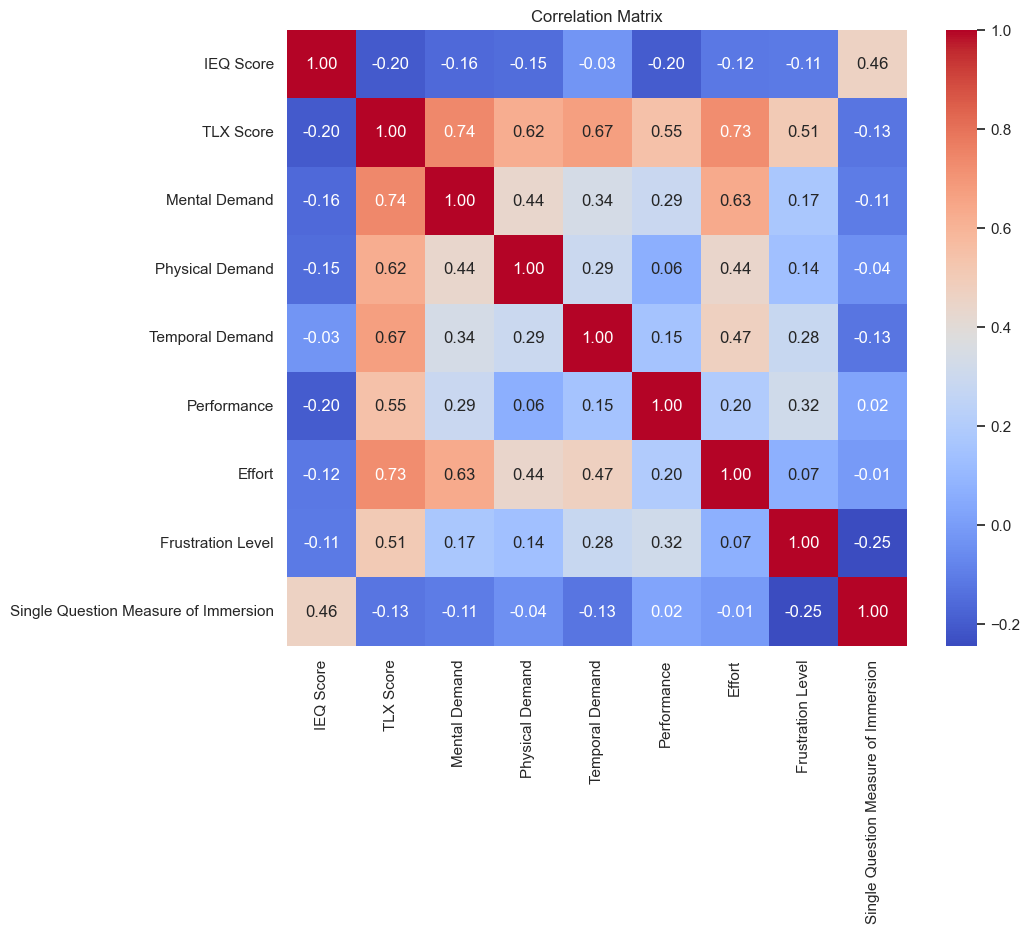

In [126]:
# Select relevant columns from merged_df for correlation analysis
corr_columns = [
    "IEQ Score",
    "TLX Score",
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level",
    "Single Question Measure of Immersion"
]

# Compute the correlation matrix
correlation_matrix = merged_df[corr_columns].corr()

# Display the correlation matrix
print("Correlation matrix for TLX, IEQ, TLX subclasses, and Single Question Measure of Immersion:")
print(correlation_matrix)

# Optional: visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [127]:
# Mann-Whitney U test (independent samples) between Performance scores for all group pairs
# and calculate effect size (Cohen's d)

# Extract Performance scores for each group from TLX_allScore
perf_a = TLX_allScore[TLX_allScore["Group"] == "Low"]["Performance"]
perf_b = TLX_allScore[TLX_allScore["Group"] == "Medium"]["Performance"]
perf_c = TLX_allScore[TLX_allScore["Group"] == "High"]["Performance"]

def mannwhitney_with_cohens_d(x, y):
    u_stat, p_val = mannwhitneyu(x, y, alternative='two-sided')
    # Cohen's d calculation
    mean_x, mean_y = np.mean(x), np.mean(y)
    std_x, std_y = np.std(x, ddof=1), np.std(y, ddof=1)
    n_x, n_y = len(x), len(y)
    # Pooled standard deviation
    pooled_std = np.sqrt(((n_x - 1) * std_x ** 2 + (n_y - 1) * std_y ** 2) / (n_x + n_y - 2))
    cohens_d = (mean_x - mean_y) / pooled_std if pooled_std > 0 else np.nan
    return u_stat, p_val, cohens_d

# Group A vs Group B
u_ab, p_ab, d_ab = mannwhitney_with_cohens_d(perf_a, perf_b)
print(f"Low vs Medium: U-statistic = {u_ab:.4f}, p-value = {p_ab:.4f}, Cohen's d = {d_ab:.4f}")

# Group A vs Group C
u_ac, p_ac, d_ac = mannwhitney_with_cohens_d(perf_a, perf_c)
print(f"Low vs High: U-statistic = {u_ac:.4f}, p-value = {p_ac:.4f}, Cohen's d = {d_ac:.4f}")

# Group B vs Group C
u_bc, p_bc, d_bc = mannwhitney_with_cohens_d(perf_b, perf_c)
print(f"Medium vs High: U-statistic = {u_bc:.4f}, p-value = {p_bc:.4f}, Cohen's d = {d_bc:.4f}")

Low vs Medium: U-statistic = 80.5000, p-value = 0.1898, Cohen's d = -0.5139
Low vs High: U-statistic = 133.0000, p-value = 0.4041, Cohen's d = 0.1887
Medium vs High: U-statistic = 152.0000, p-value = 0.1048, Cohen's d = 0.6567


In [129]:
hrv_df = pd.read_csv("combined_hrv_results.csv")

# Map HRV 'Condition' to questionnaire 'Group' naming
condition_map = {"LowFi": "Low", "MediumFi": "Medium", "HighFi": "High"}
hrv_df["Group"] = hrv_df["Condition"].map(condition_map)
hrv_df["ParticipantID"] = hrv_df["ParticipantID"].astype(str)

# Ensure participant columns are string for merging
TLX_allScore["ParticipantID"] = TLX_allScore["Participant Number"].astype(str)
IEQ_scores["ParticipantID"] = IEQ_scores["Participant Number"].astype(str)

# Merge HRV (Task phase) with questionnaire data
hrv_task = hrv_df[hrv_df["Phase"] == "Task"]
merged = pd.merge(hrv_task, TLX_allScore, on=["ParticipantID", "Group"], how="inner")
merged = pd.merge(merged, IEQ_scores, on=["ParticipantID", "Group"], how="inner", suffixes=("_TLX", "_IEQ"))

In [134]:
# H1: using OLS regression with performance as confidence and IEQ Score as predictor
model = smf.ols("Performance ~ C(Group) + Q('IEQ Score')", data=merged).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Performance   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     1.497
Date:                Sat, 24 May 2025   Prob (F-statistic):              0.233
Time:                        14:41:17   Log-Likelihood:                -170.25
No. Observations:                  37   AIC:                             348.5
Df Residuals:                      33   BIC:                             355.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             72.4165     43

In [132]:
stat, p = f_oneway(
    merged[merged["Group"] == "Low"]["HRV_RMSSD"],
    merged[merged["Group"] == "Medium"]["HRV_RMSSD"],
    merged[merged["Group"] == "High"]["HRV_RMSSD"]
)
print(f"ANOVA: F={stat:.2f}, p={p:.4f}")

ANOVA: F=0.73, p=0.4910


C:\Users\LFMde\AppData\Local\Temp\ipykernel_37740\3446723739.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(


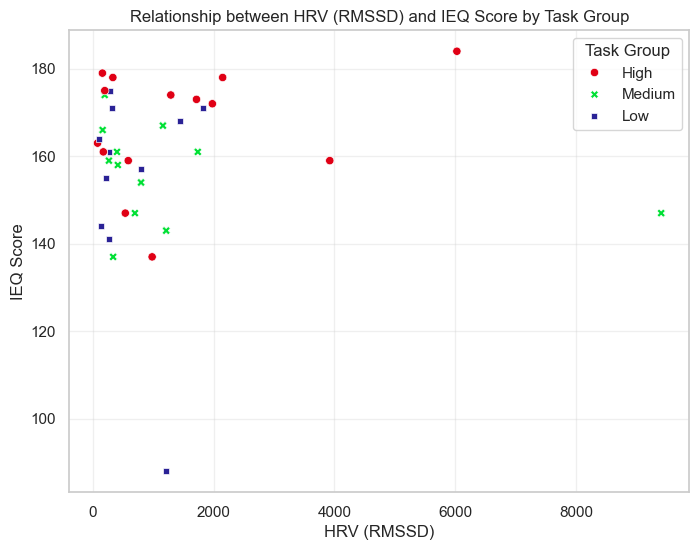

In [133]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=merged,
    x="HRV_RMSSD",
    y="IEQ Score",
    hue="Group",
    palette=custom_SNS_pallette,
    style="Group"
)
plt.title("Relationship between HRV (RMSSD) and IEQ Score by Task Group")
plt.xlabel("HRV (RMSSD)")
plt.ylabel("IEQ Score")
plt.legend(title="Task Group")
plt.grid(alpha=0.3)
plt.show()